# MW campaign: density evolution & disk projections (usage guide)

Campaign walkthrough: **configure → solve → OpenMP sample → evolve → density / disk diagnostics**. Companion to the single-run GPU DBH notebook.

| Doc / notebook | Topic |
| --- | --- |
| [`galacticsics_pipeline.md`](../docs/galacticsics_pipeline.md) | Pipeline + spiral/bar notes |
| [`ic_sampling.md`](../docs/ic_sampling.md) | OpenMP gen* (disk/**halo**/**bulge**), potential virial |
| [`ci_essential.md`](../docs/ci_essential.md) | PR test gate (`make test-essential`) |
| [`gpu_bh_dbh.ipynb`](gpu_bh_dbh.ipynb) | Single DBH galaxy + **GPU BH** + IC virial |
| [`nfw_halo_walkthrough.ipynb`](nfw_halo_walkthrough.ipynb) | Halo-only IC → BH validation → scaling |

**Default physics backend:** Python. **Default sampling:** OpenMP (`sample.use_openmp: true`) for disk, halo, and bulge when `_sampler_c` is built.

Units: kpc, 100 km/s, 2.325×10⁹ M☉, G=1; 1 code time ≈ 9.78 Myr.


## Campaign pipeline

```
CONFIG (notebook)  →  solve_potential (dbh)  →  sample (OpenMP gen*)  →  ntropy evolve
                              ↓                        ↓                      ↓
                         dbh.dat / DF tables      disk/halo[/bulge]     ρ(r), Σ(R), maps
```

Edit **`CONFIG`** in § Configuration (no JSON required). Optional: `save_config()` → `campaigns/mw_walkthrough.json`.

**Prerequisites** (repo root):

```bash
pip install -e ".[dev]"
pip install -e "src/ntropy[dev]"
python setup.py build_ext --inplace   # after C sampler/Poisson changes
# Restart Kernel
```


In [1]:
from __future__ import annotations

import copy
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

import importlib

from galacticsics.campaign import analysis as ca
importlib.reload(ca)
from galacticsics.campaign import run_config as rc
importlib.reload(rc)
from galacticsics.campaign.runner import run_campaign, run_campaign_from_config
from galacticsics.campaign.run_config import (
    build_type_registry,
    config_parameter_table,
    default_walkthrough_config,
    reload_walkthrough_context,
    sample_openmp_summary,
    save_walkthrough_config,
)
from galacticsics.campaign.spec import expand_grid
from ntropy.analysis.tiered_diagnostics import plot_tiered_diagnostics
from ntropy.integrations.galacticsics import galacticsics_available, require_galacticsics

REPO = Path.cwd()
if not (REPO / "src" / "galacticsics").exists():
    REPO = REPO.parent

CONFIG_PATH = REPO / "notebooks" / "campaigns" / "mw_walkthrough.json"

if not galacticsics_available():
    raise RuntimeError("Install galacticsics: pip install -e '.[dev]' from repo root")
require_galacticsics()

import sys

# Fast IC sampling needs the OpenMP C extension (built by editable install).
from galacticsics.sampling.openmp import extension_available, openmp_sampler_status, reload_extension
from galacticsics.sampling.sampler import SampleConfig

print(f"Python: {sys.executable}")
reload_extension()
status = openmp_sampler_status(SampleConfig(use_openmp=True))
print(f"IC sampler check: {status.log_label()}")
if not extension_available():
    print(
        "NOTE: OpenMP IC sampler extension not built — gendisk/genhalo/genbulge will use slow Python path.\n"
        "      From repo root: make install-dev  (or pip install -e '.[dev]'), then Restart Kernel."
    )
else:
    print("OpenMP extension loaded. After code updates, always Restart Kernel before re-running sample.")


Python: /home/jbauer/GalactICSIsoWithGas/.venv/bin/python3
IC sampler check: OpenMP/all cores
OpenMP extension loaded. After code updates, always Restart Kernel before re-running sample.


## Configuration (edit in notebook — no JSON required)

The next cell defines **`CONFIG`** with every parameter and its default. Edit values, then run `apply_config()`.

| Block | What it controls |
| --- | --- |
| `particles` / `softening` | N-body IC counts and ε per component |
| `sample` | IC sampler: `use_openmp` (C/OpenMP vs Python), `n_openmp_threads` (0 = all cores) |
| `base_model.grid` | DBH Poisson grid (`grid_dr`, `grid_nr`, `grid_lmax`) |
| `base_model.patch` | Galaxy physics: masses, scales, halo v₀/a, disk kinematics |
| `force` | Barnes–Hut θ, rebuild cadence, `mpi_local_trees` (LET under MPI) |

Patch keys use dot paths (`disk.mass`, `halo.v0`, …). Units: kpc, 100 km/s, GalactICS mass (≈ 2.325×10⁹ M☉).

**OpenMP sampling:** `sample.use_openmp: true` is the default for **disk, halo, and bulge**. Build with `pip install -e '.[dev]'` or `python setup.py build_ext --inplace`. **Restart the kernel** after installing so `_sampler_c` loads. See [`ic_sampling.md`](../docs/ic_sampling.md).

Optional: `save_config()` writes `mw_walkthrough.json`.


In [2]:
CONFIG = default_walkthrough_config()

# --- All parameters (defaults populated); edit any line, then apply_config() ---
CONFIG["name"] = "mw_walkthrough"
CONFIG["artifacts"]["root"] = "notebooks/artifacts/campaign_walkthrough"
CONFIG["run"]["skip_done"] = False
CONFIG["run"]["verbose"] = True
CONFIG["run"]["stages"] = ["solve", "sample", "evolve"]
CONFIG["run"]["reevolve_checkpoints"] = False
CONFIG["particles"]["disk"] = 150_000
CONFIG["particles"]["halo"] = 50_000
CONFIG["particles"]["bulge"] = 0
CONFIG["softening"]["disk"] = 0.1   # 10× legacy 0.01 kpc
CONFIG["softening"]["halo"] = 0.5   # 10× legacy 0.05 kpc
CONFIG["softening"]["bulge"] = 0.2  # 10× legacy 0.02 kpc
CONFIG["parallel"]["mpi_ranks"] = 1
CONFIG["parallel"]["core_fraction"] = 0.75
# Fast disk/halo ICs via OpenMP C extension (requires pip install -e '.[dev]', restart kernel)
CONFIG["sample"]["use_openmp"] = True
CONFIG["sample"]["n_openmp_threads"] = 0  # 0 = all logical cores
CONFIG["sample"]["run_diskdf"] = True
CONFIG["base_model"]["grid"]["name"] = "base_mw"
CONFIG["base_model"]["grid"]["base"] = "milky_way_disk_halo"
CONFIG["base_model"]["grid"]["axes"] = {}
CONFIG["base_model"]["grid"]["omit_components"] = [[]]
CONFIG["base_model"]["grid"]["coarse_grid"] = True
CONFIG["base_model"]["grid"].pop("grid_dr", None)
CONFIG["base_model"]["grid"].pop("grid_nr", None)
CONFIG["base_model"]["grid"].pop("grid_lmax", None)
CONFIG["base_model"]["grid"]["physics_backend"] = "python"
CONFIG["base_model"]["patch"]["halo.r_outer"] = 200.0
CONFIG["base_model"]["patch"]["halo.v0"] = 3.7
CONFIG["base_model"]["patch"]["halo.a"] = 33.0
CONFIG["base_model"]["patch"]["halo.dr_trunc"] = 12.0
CONFIG["base_model"]["patch"]["halo.cusp"] = 1.0
CONFIG["base_model"]["patch"]["disk.mass"] = 17.0
CONFIG["base_model"]["patch"]["disk.scale_length"] = 2.5
CONFIG["base_model"]["patch"]["disk.outer_radius"] = 20.25
CONFIG["base_model"]["patch"]["disk.scale_height"] = 0.25
CONFIG["base_model"]["patch"]["disk.trunc_width"] = 3.0
CONFIG["base_model"]["patch"]["disk.hole_radius"] = 0.0
CONFIG["base_model"]["patch"]["disk.core_radius"] = 1.5
CONFIG["base_model"]["patch"]["disk_kinematics.sigma_r0"] = 0.85
CONFIG["base_model"]["patch"]["disk_kinematics.sigma_r_scale"] = 2.8
CONFIG["base_model"]["patch"]["disk_kinematics.n_radial_steps"] = 50
CONFIG["base_model"]["patch"]["disk_kinematics.n_iterations"] = 10
CONFIG["base_model"]["patch"]["disk_kinematics.toomre_q_target"] = 1.5
CONFIG["base_model"]["patch"]["black_hole.mass"] = 0.0
CONFIG["sweep"]["enabled"] = False
CONFIG["sweep"]["grid_spec"] = "campaigns/mw_grid.json"
CONFIG["evolve"]["end_time_gyr"] = 0.5
CONFIG["evolve"]["dt_base"] = 0.05
CONFIG["evolve"]["timestep_eta"] = 0.025
CONFIG["evolve"]["max_timestep_bin"] = 7  # screening; use ≤5 for tighter |ΔE/E₀|
CONFIG["evolve"]["timestep_update_every"] = 2
CONFIG["evolve"]["integrator_order"] = 2
CONFIG["evolve"]["diagnostics_every"] = 20
CONFIG["evolve"]["particle_dump_every"] = 100
CONFIG["force"]["theta"] = 0.75
CONFIG["force"]["rebuild_every"] = 10
CONFIG["force"]["active_subset"] = True
CONFIG["force"]["mpi_local_trees"] = True  # local octrees + LET under MPI
CONFIG["force"]["bh_optimizations_preset"] = "optimized"
CONFIG["force"]["bh_optimizations"]["preset"] = "optimized"
CONFIG["force"]["bh_optimizations"]["simd_leaves"] = True
CONFIG["force"]["bh_optimizations"]["omp_schedule"] = "guided"
CONFIG["checkpoints_gyr"] = [0.0, 0.1, 0.25, 0.5]  # spans END_TIME_GYR; mid times need particle dumps


def save_config() -> None:
    save_walkthrough_config(CONFIG_PATH, CONFIG)
    print(f"Saved → {CONFIG_PATH}")


def apply_config():
    global CFG, BUDGET, BASE_SPEC, BASE_ROOT, CAMPAIGN_ROOT, CHECKPOINT_GYR
    global REEVOLVE_FOR_CHECKPOINTS, RUN_KW, END_TIME_GYR, SKIP_DONE, SWEEP_SPEC, registry, ARTIFACTS
    CFG, BUDGET = reload_walkthrough_context(CONFIG_PATH, raw=CONFIG, repo=REPO)
    BASE_SPEC = CFG.base_grid
    BASE_ROOT = CFG.paths.base_root
    CAMPAIGN_ROOT = CFG.paths.sweep_root
    ARTIFACTS = CFG.paths.artifacts
    ARTIFACTS.mkdir(parents=True, exist_ok=True)
    CHECKPOINT_GYR = CFG.checkpoints_gyr
    REEVOLVE_FOR_CHECKPOINTS = bool(CFG.run.get("reevolve_checkpoints", False))
    RUN_KW = CFG.run_campaign_kwargs()
    END_TIME_GYR = float(CFG.evolve.get("end_time_gyr", 1.0))
    SKIP_DONE = bool(CFG.run.get("skip_done", True))
    SWEEP_SPEC = CFG.sweep_grid()
    registry = build_type_registry(CONFIG)
    print(sample_openmp_summary(CONFIG))
    return CFG


from galacticsics.campaign.spec import model_component_parameter_table

apply_config()
display(config_parameter_table(CONFIG))
print()
for line in CFG.summary_lines():
    print(line)
print()
_, preview_model = CFG.base_model()
display(model_component_parameter_table(preview_model))


Sample: OpenMP C samplers (all cores)


,parameter,value
0,artifacts.root,notebooks/artifacts/campaign_walkthrough
1,base_model.grid.axes,{}
2,base_model.grid.base,milky_way_disk_halo
3,base_model.grid.coarse_grid,True
4,base_model.grid.name,base_mw
...,...,...
60,solve.n_workers,0
61,solve.nint,20
62,solve.npsi,1000
63,sweep.enabled,False



Config: mw_walkthrough.json
Particles: disk=150,000, halo=50,000 (total 200,000)
Softening ε [kpc]: bulge=0.2, disk=0.1, halo=0.5
Evolve: 0.5 Gyr | verbose: True
Tiered timestep:
  dt_base     : 0.05000 code (0.489 Myr, bin 0)
  dt_max      : 6.4000 code (62.59 Myr, bin 7)
  eta         : 0.025
  bin update  : every 2 fine substep(s)
  integrator  : order-2 leapfrog
  duration    : 0.5 Gyr = 51.12 code units in 1022 fine substeps
DBH grid: dr=0.05 kpc, nr=4000, lmax=4 (r_max ≈ 200 kpc; cost scales ~ nr × lmax²)
Force: theta=0.75, rebuild_every=10, active_subset=True, mpi_local_trees=True, bh=optimized
Parallel: 8 cores → budget 6 (MPI 1 × OMP 6 = 6)
Sample: OpenMP C samplers (all cores)
Artifacts → /home/jbauer/GalactICSIsoWithGas/notebooks/artifacts/campaign_walkthrough
Model patch: {'halo.r_outer': 200.0, 'halo.v0': 3.7, 'halo.a': 33.0, 'halo.dr_trunc': 12.0, 'halo.cusp': 1.0, 'disk.mass': 17.0, 'disk.scale_length': 2.5, 'disk.outer_radius': 20.25, 'disk.scale_height': 0.25, 'disk.t

,parameter,value,enabled
0,halo.r_outer,200.00,True
1,halo.v0,3.70,True
2,halo.a,33.00,True
3,halo.dr_trunc,12.00,True
4,halo.cusp,1.00,True
5,disk.mass,17.00,True
6,disk.scale_length,2.50,True
7,disk.outer_radius,20.25,True
8,disk.scale_height,0.25,True
9,disk.trunc_width,3.00,True


## 1. Base Milky Way simulation (reference case)

Run the default `milky_way_disk_halo` model using settings from `mw_walkthrough.json`:

- Edit **`notebooks/campaigns/mw_walkthrough.json`** to change particles, DBH grid, Toomre Q, evolve duration, or force knobs
- `run_campaign_from_config` writes `ntropy_config.json` per model (tiered leapfrog, optimized `bh_c`, active-subset forces)

Outputs land in `base_mw/{hash}/`.

In [3]:
# Analysis helpers (plot_density_map uses percentile contrast for projections)
import importlib

importlib.reload(ca)

from ntropy.analysis.density import compare_density_profiles
from ntropy.analysis.disk_density import compare_surface_profiles
from ntropy.softening import kinetic_energy, total_energy

from galacticsics.campaign.benchmarks import diagnose_ic_stability, explain_ic_instability, ic_looks_stable
from galacticsics.campaign.analysis import load_ic_state

load_merged_state = ca.load_merged_state
load_evolved_state = ca.load_evolved_state
halo_spherical_profile = ca.halo_spherical_profile
halo_profile_bin_edges = ca.halo_profile_bin_edges
halo_projections = ca.halo_projections
plot_halo_spherical_profile = ca.plot_halo_spherical_profile
HALO_PROFILE_MIN_COUNT = ca.HALO_PROFILE_MIN_COUNT
HALO_PROFILE_PLOT_MIN_COUNT = ca.HALO_PROFILE_PLOT_MIN_COUNT
halo_profile_min_count = ca.halo_profile_min_count
summarize_evolution_health = ca.summarize_evolution_health
validate_ic_distribution_functions = ca.validate_ic_distribution_functions
validate_halo_df = ca.validate_halo_df
validate_disk_df = ca.validate_disk_df
validate_bulge_df = ca.validate_bulge_df
state_virial_summary = ca.state_virial_summary
disk_axisymmetry_diagnostic = ca.disk_axisymmetry_diagnostic
projection_colorbar_label = ca.projection_colorbar_label
component_radial_stats = ca.component_radial_stats
disk_surface_profile = ca.disk_surface_profile
disk_projections = ca.disk_projections
load_run_diagnostics = ca.load_run_diagnostics
model_summary_table = ca.model_summary_table
density_drift_metrics = ca.density_drift_metrics
analytic_halo_overlay = ca.analytic_halo_overlay
load_rotation_curve = ca.load_rotation_curve
plot_density_map = ca.plot_density_map
density_map_color_limits = ca.density_map_color_limits
add_density_colorbar = ca.add_density_colorbar
load_evolution_checkpoints = ca.load_evolution_checkpoints
evolution_checkpoint_times = ca.evolution_checkpoint_times


### 1a. Run solve → sample → evolve for the base model

In [4]:
base_label, BASE_MODEL = CFG.base_model()
display(model_summary_table(BASE_MODEL))

base_manifest = run_campaign_from_config(
    CONFIG_PATH, work_root=BASE_ROOT, grid_spec=BASE_SPEC, raw=CONFIG, repo=REPO
)

base_row = base_manifest.rows[0]
BASE_WORK_DIR = Path(base_row["path"])
print(f"Base model: {base_label}")
print(f"Work dir: {BASE_WORK_DIR}")
if "toomre_q" in base_row:
    print(f"Toomre Q (2.5 R_d): {base_row['toomre_q']:.3f}")
pd.DataFrame([base_row])

,parameter,value
0,halo.r_outer,200.00
1,halo.v0,3.70
2,halo.a,33.00
3,disk.mass,17.00
4,disk.scale_length,2.50
5,disk.scale_height,0.25
6,disk_kinematics.sigma_r0,0.85
7,disk_kinematics.toomre_q_target,1.50
8,grid.nr,4000.00
9,grid.lmax,4.00


[19:25:13] ========================================================================
[19:25:13] Campaign 'base_mw' → /home/jbauer/GalactICSIsoWithGas/notebooks/artifacts/campaign_walkthrough/base_mw
[19:25:13] Stages: solve, sample, evolve | models: 1
[19:25:13]   particles: disk=150,000, halo=50,000
[19:25:13]   end_time_gyr: 0.5
[19:25:13]   dt_base: 0.05
[19:25:13]   mpi_ranks: 1
[19:25:13]   core_fraction: 0.75
[19:25:13]   bh_optimizations: optimized
[19:25:13]   force_theta: 0.75
[19:25:13]   force_active_subset: True
[19:25:13]   force_rebuild_every: 10
[19:25:13]   softening_kpc: {'disk': 0.1, 'halo': 0.5, 'bulge': 0.2}
[19:25:13]   diagnostics_every: 20
[19:25:13]   skip_done: False
[19:25:13]   physics_backend: python
[19:25:13] ========================================================================
[19:25:13] ------------------------------------------------------------------------
[19:25:13] Model [1/1] full  hash=c8c47a84e4cc…
  dir: /home/jbauer/GalactICSIsoWithGas/noteboo

full:   0%|          | 0/3 [00:00<?, ?stage/s]

[19:25:13] ▶ solve — dbh (nr=4000, lmax=4)
[19:25:13]   legacy: dbh (python)  (cwd=/home/jbauer/GalactICSIsoWithGas/notebooks/artifacts/campaign_walkthrough/base_mw/c8c47a84e4cc)
[19:26:48]   ✓ solve finished in 1.6m | rtidal=200 | solve_seconds=94.98
[19:26:48] ▶ sample — disk=150,000, halo=50,000
[19:26:48]   IC sampler: OpenMP/all cores
[19:26:48]   legacy: diskdf [python]  (cwd=/home/jbauer/GalactICSIsoWithGas/notebooks/artifacts/campaign_walkthrough/base_mw/c8c47a84e4cc)
[19:26:48] Toomre Q = 1.5000 at R = 6.250 kpc (sigma_r0 = 1.1810, sigma_r_scale = 2.800 kpc); target Q = 1.5000
[19:27:01]   legacy: gendisk [OpenMP/all cores]  (cwd=/home/jbauer/GalactICSIsoWithGas/notebooks/artifacts/campaign_walkthrough/base_mw/c8c47a84e4cc)
[19:27:03]   gendisk: 150,000/150,000 particles (OpenMP)
[19:27:05]   legacy: genhalo [OpenMP/all cores]  (cwd=/home/jbauer/GalactICSIsoWithGas/notebooks/artifacts/campaign_walkthrough/base_mw/c8c47a84e4cc)
[19:27:05]   genhalo: 50,000/50,000 particles (Ope

=== full evolve ===
  integrator : tiered_leapfrog, order=2
  dt_base    : 0.05000 code units
  end_time   : 0.5 Gyr
  n_substeps : 1022 (fine, global clock)
  duration   : 0.5 Gyr = 51.12 code units in 1022 fine substeps (dt_base=0.05000)
  force      : bh_c (theta=0.75)
  parallel   : off
  seed       : 42
[ntropy] full evolve: N=200,000, 1022 fine substeps → 0.5 Gyr (dt_base=0.05000)
[ntropy] initial force evaluation…
step    0/1022 | t=0.0000 Gyr | active 100.0% (200000) | dE/E0=0.00e+00 | bins 155667,22964,21367,2,0,0,0,0 | disk μb=0.0 halo μb=1.3
[ntropy] integrating…
step   20/1022 | t=0.0098 Gyr | active 100.0% (199998) | dE/E0=3.67e-04 | bins 155623,22983,21392,2,0,0,0,0 | disk μb=0.0 halo μb=1.3
step   40/1022 | t=0.0196 Gyr | active 100.0% (200000) | dE/E0=8.21e-04 | bins 155487,23085,21427,1,0,0,0,0 | disk μb=0.0 halo μb=1.3
step   60/1022 | t=0.0293 Gyr | active 100.0% (200000) | dE/E0=2.46e-03 | bins 155348,23184,21468,0,0,0,0,0 | disk μb=0.0 halo μb=1.3
step   80/1022 | 

[19:50:05]   ✓ evolve finished in 23.0m | evolve_seconds=1376 | dE_over_E0=0.05905 | n_energies=2 | n_ranks=1 | mpi=False
[19:50:05] Model done in 24.9m
[19:50:05] ========================================================================
[19:50:05] Campaign complete: 1 model(s) in 24.9m
[19:50:05] ========================================================================
Base model: full
Work dir: /home/jbauer/GalactICSIsoWithGas/notebooks/artifacts/campaign_walkthrough/base_mw/c8c47a84e4cc
Toomre Q (2.5 R_d): 1.500


,label,hash,path,solve_seconds,rtidal,work_dir,sample_seconds,particles_dir,n_particles,n_disk,n_halo,toomre_q,ic_velocity_diag,rotation_curve_ic,evolve_seconds,dE_over_E0,n_energies,n_ranks,mpi,rotation_curve_final
0,full,c8c47a84e4cc,/home/jbauer/GalactICSIsoWithGas/notebooks/art...,94.983476,200.0,/home/jbauer/GalactICSIsoWithGas/notebooks/art...,17.587095,/home/jbauer/GalactICSIsoWithGas/notebooks/art...,200000,150000,50000,1.5,"{'r_max': 237.222683228267, 'disk_v_max': 4.35...",/home/jbauer/GalactICSIsoWithGas/notebooks/art...,1375.887332,0.059046,2,1,False,/home/jbauer/GalactICSIsoWithGas/notebooks/art...


### 1b. Detailed base-case diagnostics

Particle counts, halo **ρ(r)** (spherical shells) and disk **Σ(R)** at t=0 vs t=`END_TIME_GYR`, plus **projected surface-density maps** (face-on / edge-on). These are the reference against which grid variants should be compared.

**How to read the plots**

| Panel | Quantity | Notes |
|-------|----------|-------|
| Halo ρ(r) | Spherical mass density | Shells with &lt;50 particles (IC) or &lt;25 (evolved) are masked — evolved halos often **start at r≈10–15 kpc** because inner shells empty after heating. Gray twin axis = particles/shell. |
| Halo face-on / edge-on | **Projected Σ**, not ρ(r) | Grainy blobs are expected for 50k collisionless tracers; these are *not* disk maps. |
| Disk Σ(R) | Midplane surface density | Integrated over all \|z\| unless noted. |
| Disk face-on / edge-on | Projected Σ | Axisymmetric at $t=0$; spirals/bars can grow over **multi-Gyr** from shot noise + swing amplification ([Bauer & Widrow 2018](https://arxiv.org/pdf/1809.00090v1)). |
| Virial check | Prefer **potential** $2K/\|W\|$ on ICs (`virial_diagnostic_potential`); pairwise softened $2T/\|W\|$ is informational | Equilibrium in $\Psi$ expects $\approx 1$ at $t=0$; see [`ic_sampling.md`](../docs/ic_sampling.md). Softened $N$-body virial can look “hot” for dense components. |
| Disk $A_2/A_0$ | Azimuthal Fourier (Fig. 4) | Shot-noise floor $\sim 1/\sqrt{N}$ at $t=0$; growth above floor over Gyr signals bars/spirals. |

**Spiral and bar formation.** GalactICS ICs are axisymmetric equilibria with uniform azimuth and finite-$N$ shot noise. [Bauer & Widrow (2018)](https://arxiv.org/pdf/1809.00090v1) evolve similar GalactICS disks to 5–10 Gyr ($Q\approx 2.34$, $\varepsilon=0.15$ kpc) and show spirals in Figure 5 without an external perturbation. This walkthrough uses **0.5 Gyr**, `toomre_q_target=1.5`, and coarse `max_timestep_bin=7` — too short and too heated for morphology. See [`docs/galacticsics_pipeline.md`](../docs/galacticsics_pipeline.md) § *Spiral and bar formation* and `campaigns/bauer_morphology.json` for a paper-ish preset (`end_time_gyr≥5`, $Q\sim 2.34$, tighter timesteps).

**Screening settings** (N≈3×10⁵, 0.5 Gyr, `max_timestep_bin=7`, halo ε=0.5 kpc) routinely give |ΔE/E₀|≳0.2 and order-of-magnitude halo ρ drift. That is **real collisionless heating** (large timesteps + softening + disk–halo coupling), not a plotting artifact. For tighter evolution: `end_time_gyr≤0.1`, `max_timestep_bin≤5`, `particles.halo≥10⁵`, or production softening.
**Multi-time face-on maps.** After the t=0 vs final panels below, a second figure plots disk **face-on Σ** at every time in `CONFIG["checkpoints_gyr"]` plus `END_TIME_GYR`, loaded from campaign `evolution/particles/step_*.npz` dumps (see :func:`~galacticsics.campaign.analysis.load_evolution_checkpoints`). For multi-Gyr morphology studies use `campaigns/bauer_morphology.json` checkpoints ([Bauer & Widrow 2018](https://arxiv.org/pdf/1809.00090v1)).


IC velocity check: {'r_max': 237.222683228267, 'disk_v_max': 4.353292732374912, 'disk_v_median': 1.6683160365048266, 'disk_v_phi_mean': 1.3078104865232385, 'disk_v_phi_median': 1.5099412729609094, 'disk_r_median': 4.306035730568885, 'disk_v_phi_positive_frac': 0.9411133333333334, 'halo_v_max': 4.476817320347563, 'halo_v_median': 1.3355231602293332}
N = 200,000 particles
  halo : 50,000
  disk : 150,000
|ΔE/E₀| after 0.5 Gyr: 5.905e-02 (KE proxy at N=200,000)
Campaign-reported |ΔE/E₀|: 5.905e-02
Max relative halo ρ drift: 0.384
Max relative disk Σ drift: 6.634

Evolution health summary:
  dE_over_E0: 0.05905
  virial_ic_virial_ratio: 2.968
  virial_ic_is_virial_equilibrium: False
  virial_final_virial_ratio: 2.839
  disk_m2_a0_median_ic: 0.01165
  disk_m2_a0_median_final: 0.2814
  df_validation_pass: False
  df_halo_energy_df_max_log_rel: 0.2537
  df_disk_surface_density_max_rel: 0.1013
  df_disk_a2_over_a0_median: 0.004266
  halo_rho_drift: 0.3837
  disk_sigma_drift: 6.634
  halo_r_med

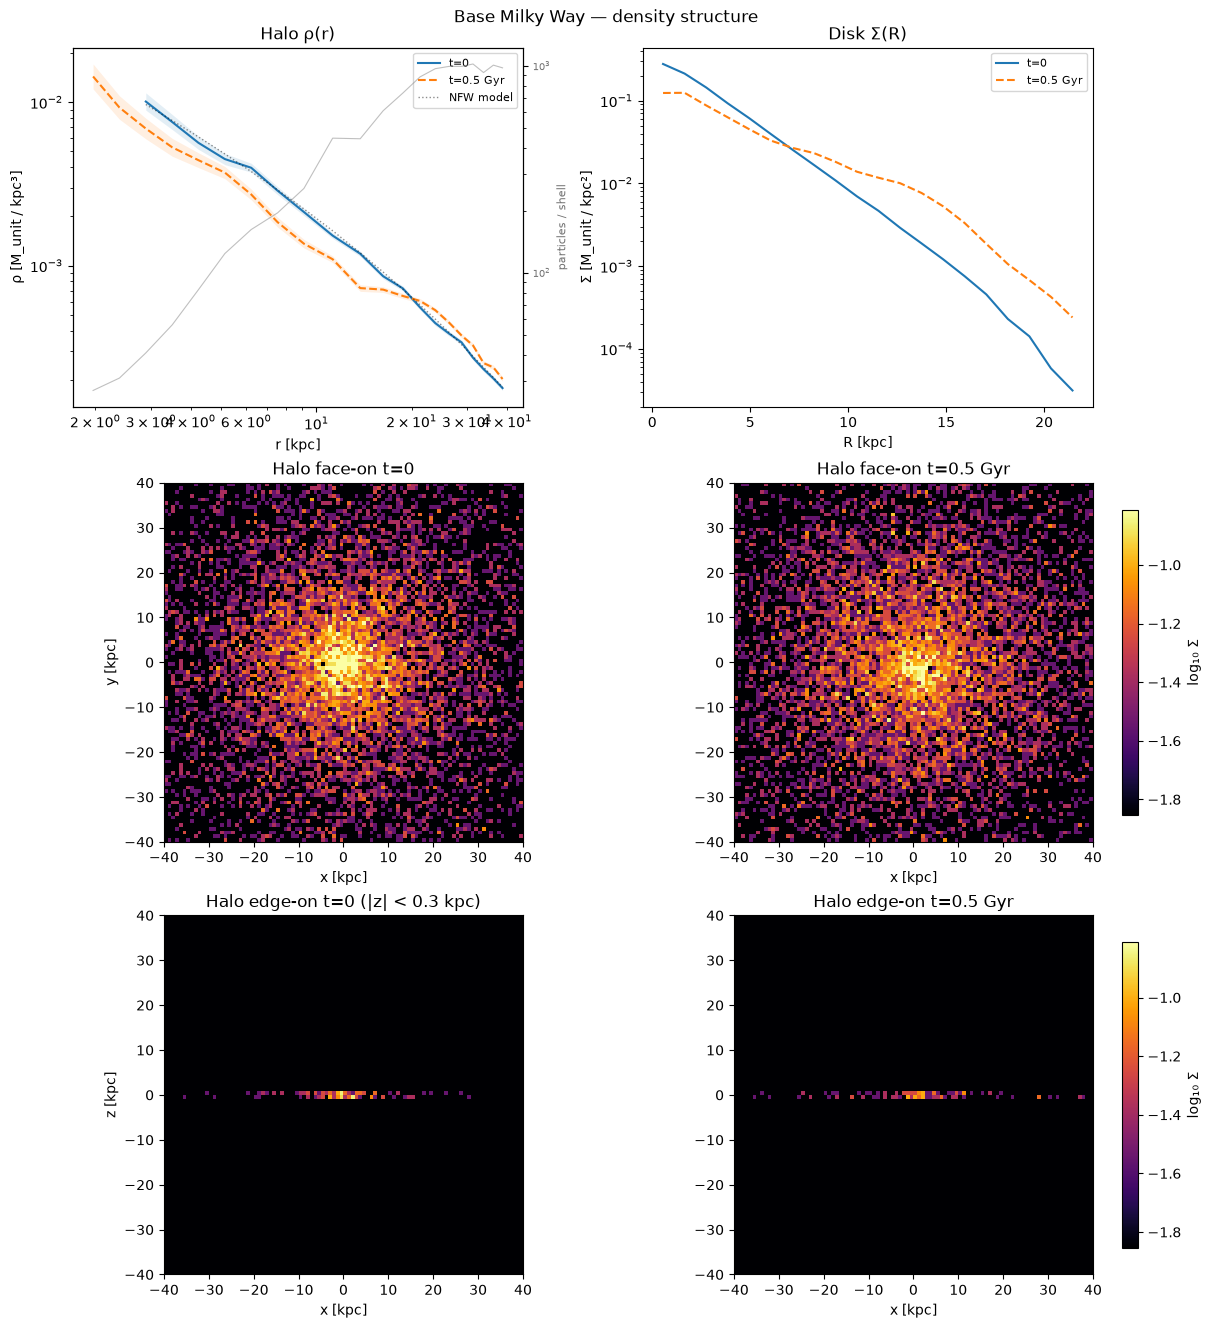

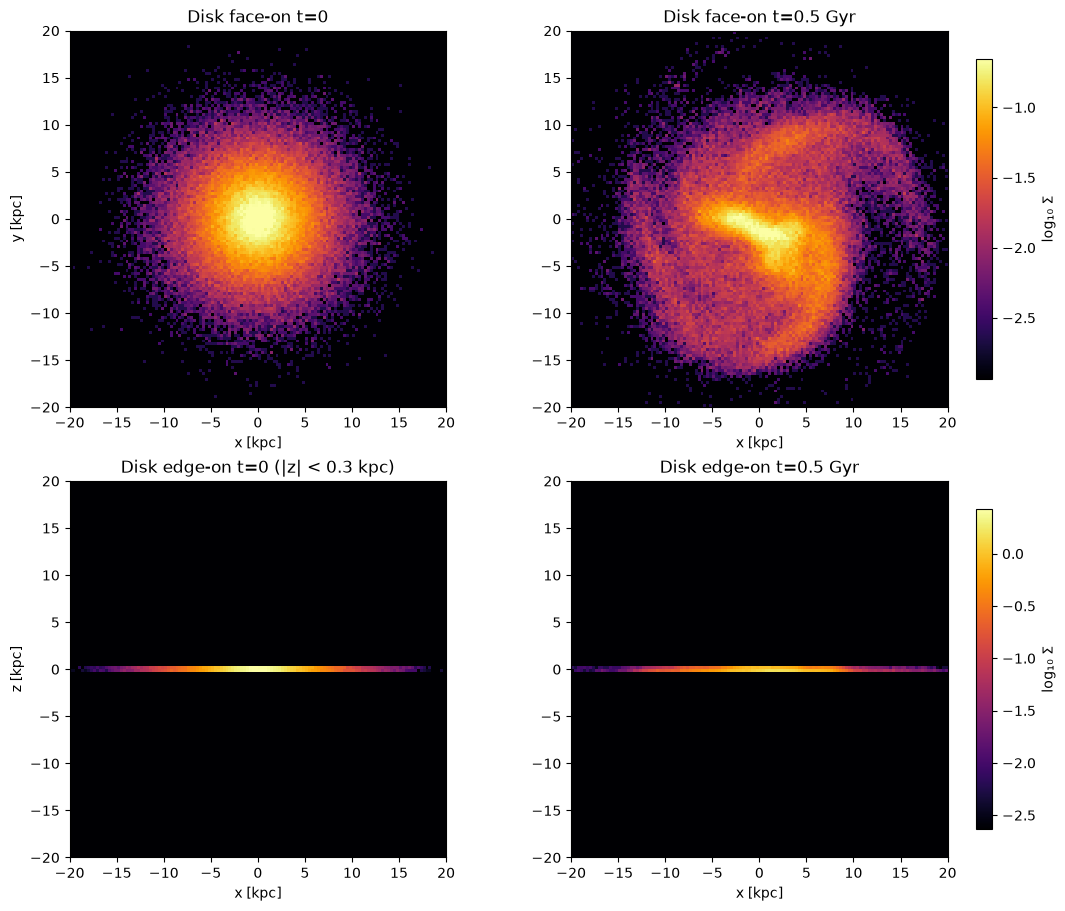

Saved base_density_diagnostics.png, base_disk_projections.png
Disk face-on checkpoints: t=0.000 Gyr, t=0.098 Gyr, t=0.500 Gyr (requested [0.0, 0.1, 0.25, 0.5])


/tmp/ipykernel_45088/1691356617.py:283: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


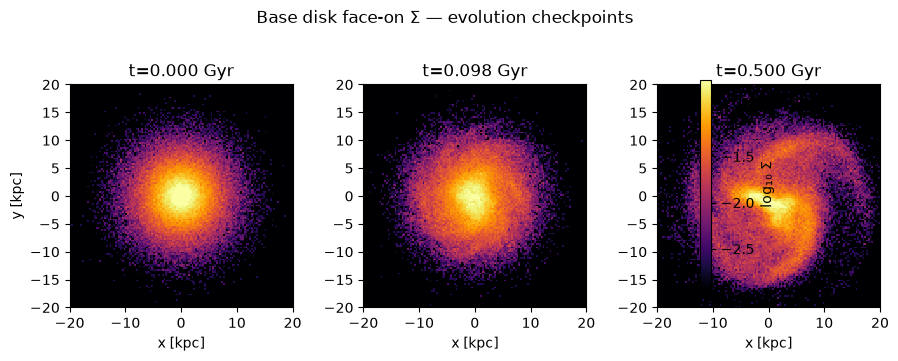

Saved base_disk_faceon_evolution.png


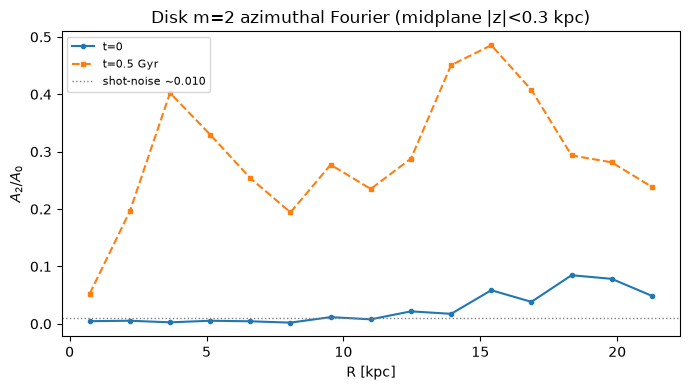

A2/A0 median: IC=0.01165, final=0.2814 (noise floor ~0.01033)
Saved base_disk_a2_fourier.png


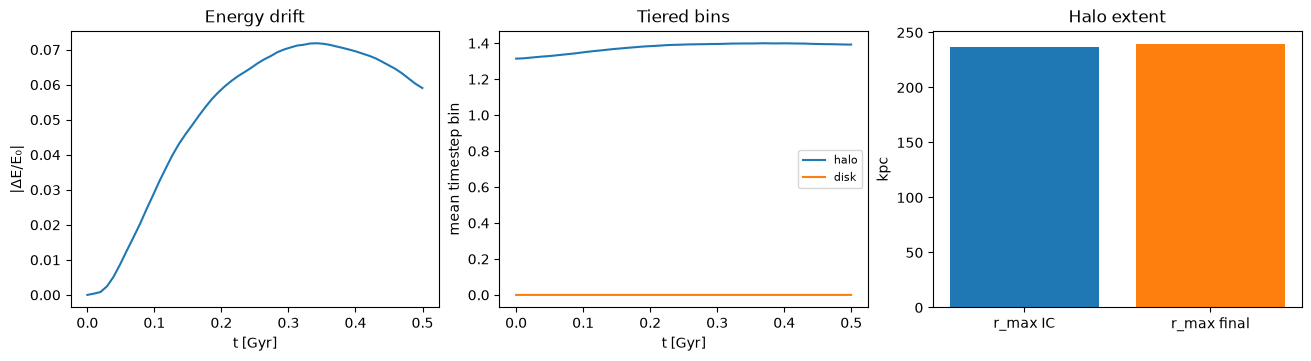

Saved base_evolution_health.png


In [6]:
from galacticsics.campaign.benchmarks import invalidate_ic_artifacts
from galacticsics.campaign.spec import format_dbh_grid_summary


def _load_base_states():
    initial = load_merged_state(BASE_WORK_DIR)
    final = load_evolved_state(BASE_WORK_DIR, initial)
    return initial, final


def _ensure_stable_base_ics(*, retries: int = 1):
    """Re-run solve→sample→evolve when skip_done left stale cordbh / particle files."""
    global base_initial, base_final, base_row, base_manifest

    base_initial, base_final = _load_base_states()
    ic_diag = diagnose_ic_stability(base_initial)
    print(f"IC velocity check: {ic_diag}")
    if ic_looks_stable(base_initial):
        return ic_diag

    if retries < 1:
        base_model = ca.load_model_json(BASE_WORK_DIR)
        raise RuntimeError(
            f"Disk IC velocities look unstable: {explain_ic_instability(state=base_initial)}\n"
            f"diag={ic_diag}\n"
            f"{format_dbh_grid_summary(base_model)}\n"
            "Re-run solve→sample with skip_done=False (stale cordbh.dat is a common cause). "
            "With coarse_grid=True keep lmax≤4; use coarse_grid=False for production lmax=6 solves."
        )

    removed = invalidate_ic_artifacts(BASE_WORK_DIR)
    print(
        "Unstable ICs detected — re-running solve→sample→evolve "
        f"(removed {', '.join(removed) or 'no cached files'})"
    )
    saved_skip = CONFIG["run"]["skip_done"]
    CONFIG["run"]["skip_done"] = False
    apply_config()
    base_manifest = run_campaign_from_config(
        CONFIG_PATH, work_root=BASE_ROOT, grid_spec=BASE_SPEC, raw=CONFIG, repo=REPO
    )
    base_row = base_manifest.rows[0]
    CONFIG["run"]["skip_done"] = saved_skip
    return _ensure_stable_base_ics(retries=retries - 1)


ic_diag = _ensure_stable_base_ics(retries=1)
base_final = load_evolved_state(BASE_WORK_DIR, base_initial)
if base_final is None:
    raise FileNotFoundError("Base evolve stage did not write evolution/final.dat")

print(f"N = {base_initial.n:,} particles")
for label in registry.types:
    mask = base_initial.tags == label
    if np.any(mask):
        print(f"  {label:5s}: {mask.sum():6,d}")

# total_energy uses kinetic-only for N > 16k (see ntropy.softening.LARGE_N_ENERGY_THRESHOLD)
e0 = total_energy(base_initial.pos, base_initial.vel, base_initial.mass, base_initial.eps)
ef = total_energy(base_final.pos, base_final.vel, base_final.mass, base_final.eps)
base_dE = abs(ef - e0) / max(abs(e0), 1e-30)
print(f"|ΔE/E₀| after {END_TIME_GYR} Gyr: {base_dE:.3e} (KE proxy at N={base_initial.n:,})")
if "dE_over_E0" in base_row:
    print(f"Campaign-reported |ΔE/E₀|: {base_row['dE_over_E0']:.3e}")

# --- profiles: initial vs final (shared halo shell edges) ---
halo_edges = halo_profile_bin_edges()
halo_i = halo_spherical_profile(base_initial, bin_edges=halo_edges)
halo_f = halo_spherical_profile(base_final, bin_edges=halo_edges)
disk_i = disk_surface_profile(base_initial)
disk_f = disk_surface_profile(base_final)
halo_drift = compare_density_profiles(halo_i, halo_f, min_count=HALO_PROFILE_MIN_COUNT)
disk_drift = compare_surface_profiles(disk_i, disk_f, min_count=20)
print(f"Max relative halo ρ drift: {halo_drift:.3f}")
print(f"Max relative disk Σ drift: {disk_drift:.3f}")

base_diag_df, _ = load_run_diagnostics(BASE_WORK_DIR)
health = summarize_evolution_health(
    base_initial,
    base_final,
    model=ca.load_model_json(BASE_WORK_DIR),
    work_dir=BASE_WORK_DIR,
    diagnostics_df=base_diag_df,
)
print("\nEvolution health summary:")
for key in (
    "dE_over_E0",
    "virial_ic_virial_ratio",
    "virial_ic_is_virial_equilibrium",
    "virial_final_virial_ratio",
    "disk_m2_a0_median_ic",
    "disk_m2_a0_median_final",
    "df_validation_pass",
    "df_halo_energy_df_max_log_rel",
    "df_disk_surface_density_max_rel",
    "df_disk_a2_over_a0_median",
    "halo_rho_drift",
    "disk_sigma_drift",
    "halo_r_median_shift_kpc",
    "halo_ic_nfw_median_ratio",
    "halo_final_nfw_median_ratio",
    "diag_halo_mean_bin",
):
    if key in health:
        val = health[key]
        if isinstance(val, (bool, np.bool_)):
            print(f"  {key}: {val}")
        elif isinstance(val, (int, float, np.floating)):
            print(f"  {key}: {val:.4g}")
        else:
            print(f"  {key}: {val}")

df_report = validate_ic_distribution_functions(
    base_initial, ca.load_model_json(BASE_WORK_DIR), BASE_WORK_DIR
)
print("\nIC distribution-function validation:")
for comp in ("halo", "disk", "bulge"):
    rep = df_report.get(comp, {})
    if rep.get("skipped"):
        continue
    status = "PASS" if rep.get("pass") else "FAIL"
    print(f"  {comp}: {status} (n={rep.get('n', 0):,})")
    for metric in (
        "energy_df_max_log_rel",
        "speed_in_bounds_frac",
        "surface_density_max_rel",
        "sigma_r0_ratio",
        "a2_over_a0_median",
        "cordbh_f_d_min",
        "df_positive_frac",
    ):
        if metric in rep:
            print(f"    {metric}: {rep[metric]:.4g}")
print(f"  overall DF pass: {df_report.get('overall_pass')}")
print(
    "  Note: low A2/A0 at t=0 is expected (shot noise). "
    "Spirals/bars grow over multi-Gyr (Bauer & Widrow 2018); "
    "this 0.5 Gyr screen is too short for morphology."
)

DISK_PROFILE_MIN_COUNT = 20
if base_dE > 0.12 or halo_drift > 0.75 or disk_drift > 0.75:
    print(
        "⚠ Evolution looks heated for screening settings "
        f"(|ΔE/E₀|={base_dE:.3f}, halo ρ drift={halo_drift:.2f}, disk Σ drift={disk_drift:.2f}). "
        "Try shorter end_time_gyr, max_timestep_bin≤5, or higher N before interpreting morphology."
    )

base_model = ca.load_model_json(BASE_WORK_DIR)

fig, axes = plt.subplots(3, 2, figsize=(12, 13), constrained_layout=True)

plot_halo_spherical_profile(
    axes[0, 0],
    halo_i,
    halo_f,
    model=base_model,
    end_time_gyr=END_TIME_GYR,
    min_count=HALO_PROFILE_MIN_COUNT,
    min_count_final=HALO_PROFILE_PLOT_MIN_COUNT,
)

vi, vf = disk_i.counts >= DISK_PROFILE_MIN_COUNT, disk_f.counts >= DISK_PROFILE_MIN_COUNT
axes[0, 1].semilogy(disk_i.r_mid[vi], disk_i.sigma[vi], "C0-", label="t=0", ms=3)
axes[0, 1].semilogy(disk_f.r_mid[vf], disk_f.sigma[vf], "C1--", label=f"t={END_TIME_GYR} Gyr", ms=3)
axes[0, 1].set_xlabel("R [kpc]")
axes[0, 1].set_ylabel("Σ [M_unit / kpc²]")
axes[0, 1].set_title("Disk Σ(R)")
axes[0, 1].legend(fontsize=8)

halo_face_i, halo_edge_i = halo_projections(base_initial)
halo_face_f, halo_edge_f = halo_projections(base_final)
halo_vmin, halo_vmax = density_map_color_limits(
    halo_face_i, halo_face_f, halo_edge_i, halo_edge_f
)

im_hf0 = plot_density_map(
    axes[1, 0], halo_face_i, title="Halo face-on t=0", vmin=halo_vmin, vmax=halo_vmax
)
im_hf1 = plot_density_map(
    axes[1, 1],
    halo_face_f,
    title=f"Halo face-on t={END_TIME_GYR} Gyr",
    vmin=halo_vmin,
    vmax=halo_vmax,
)
for ax in axes[1, :]:
    ax.set_xlabel("x [kpc]")
axes[1, 0].set_ylabel("y [kpc]")
add_density_colorbar(fig, im_hf1, axes[1, :], label=projection_colorbar_label("halo"))

im_he0 = plot_density_map(
    axes[2, 0],
    halo_edge_i,
    title="Halo edge-on t=0 (|z| < 0.3 kpc)",
    vmin=halo_vmin,
    vmax=halo_vmax,
)
im_he1 = plot_density_map(
    axes[2, 1],
    halo_edge_f,
    title=f"Halo edge-on t={END_TIME_GYR} Gyr",
    vmin=halo_vmin,
    vmax=halo_vmax,
)
for ax in axes[2, :]:
    ax.set_xlabel("x [kpc]")
axes[2, 0].set_ylabel("z [kpc]")
add_density_colorbar(fig, im_he1, axes[2, :], label=projection_colorbar_label("halo"))

fig.suptitle("Base Milky Way — density structure", y=1.01)
base_profile_path = ARTIFACTS / "base_density_diagnostics.png"
fig.savefig(base_profile_path, dpi=150, bbox_inches="tight")
plt.show()

# --- disk projections (separate figure) ---
face_i, edge_i = disk_projections(base_initial)
face_f, edge_f = disk_projections(base_final)
fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
face_vmin, face_vmax = density_map_color_limits(face_i, face_f)
edge_vmin, edge_vmax = density_map_color_limits(edge_i, edge_f)
im0 = plot_density_map(axes[0, 0], face_i, title="Disk face-on t=0", vmin=face_vmin, vmax=face_vmax)
im1 = plot_density_map(
    axes[0, 1], face_f, title=f"Disk face-on t={END_TIME_GYR} Gyr", vmin=face_vmin, vmax=face_vmax
)
for ax in axes[0, :]:
    ax.set_xlabel("x [kpc]")
axes[0, 0].set_ylabel("y [kpc]")
add_density_colorbar(fig, im1, axes[0, :], label="log₁₀ Σ")

plot_density_map(
    axes[1, 0], edge_i, title="Disk edge-on t=0 (|z| < 0.3 kpc)", vmin=edge_vmin, vmax=edge_vmax
)
im3 = plot_density_map(
    axes[1, 1], edge_f, title=f"Disk edge-on t={END_TIME_GYR} Gyr", vmin=edge_vmin, vmax=edge_vmax
)
for ax in axes[1, :]:
    ax.set_xlabel("x [kpc]")
axes[1, 0].set_ylabel("z [kpc]")
add_density_colorbar(fig, im3, axes[1, :], label="log₁₀ Σ")

disk_proj_path = ARTIFACTS / "base_disk_projections.png"
fig.savefig(disk_proj_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {base_profile_path.name}, {disk_proj_path.name}")

# --- disk face-on maps at CONFIG checkpoints + final (campaign particle dumps) ---
base_checkpoint_times = evolution_checkpoint_times(CHECKPOINT_GYR, end_time_gyr=END_TIME_GYR)
base_evolution_slices = load_evolution_checkpoints(
    BASE_WORK_DIR,
    CHECKPOINT_GYR,
    template=base_initial,
    end_time_gyr=END_TIME_GYR,
)
print(
    "Disk face-on checkpoints:",
    ", ".join(f"t={t:.3f} Gyr" for t, _ in base_evolution_slices),
    f"(requested {base_checkpoint_times})",
)
if len(base_evolution_slices) >= 2:
    n_ck = len(base_evolution_slices)
    fig, axes = plt.subplots(1, n_ck, figsize=(3.0 * n_ck, 3.2), squeeze=False)
    face_maps = []
    for t_gyr, st in base_evolution_slices:
        face_map, _ = disk_projections(st)
        face_maps.append(face_map)
    ck_vmin, ck_vmax = density_map_color_limits(*face_maps)
    last_im = None
    for col, ((t_gyr, _), face_map) in enumerate(zip(base_evolution_slices, face_maps)):
        ax = axes[0, col]
        last_im = plot_density_map(
            ax,
            face_map,
            title=f"t={t_gyr:.3f} Gyr",
            vmin=ck_vmin,
            vmax=ck_vmax,
        )
        ax.set_xlabel("x [kpc]")
        if col == 0:
            ax.set_ylabel("y [kpc]")
    add_density_colorbar(fig, last_im, axes[0, :], label=projection_colorbar_label("disk"))
    fig.suptitle("Base disk face-on Σ — evolution checkpoints", y=1.04)
    fig.tight_layout()
    ck_path = ARTIFACTS / "base_disk_faceon_evolution.png"
    fig.savefig(ck_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {ck_path.name}")
else:
    print(
        "Need ≥2 evolution slices for the checkpoint grid — re-run evolve with "
        "particle_dump_every>0 or set REEVOLVE_FOR_CHECKPOINTS=True in §5."
    )


# --- A2/A0 vs radius (Bauer & Widrow 2018 Fig. 4 style) ---
ax_ic = disk_axisymmetry_diagnostic(base_initial, m=2, n_bins=15, r_max=22.0)
ax_fn = disk_axisymmetry_diagnostic(base_final, m=2, n_bins=15, r_max=22.0)
n_disk = int((base_initial.tags == "disk").sum())
a2_noise = 4.0 / np.sqrt(max(n_disk, 1))
fig, ax = plt.subplots(figsize=(7, 4))
valid_i = np.isfinite(ax_ic["a_m_over_a0"])
valid_f = np.isfinite(ax_fn["a_m_over_a0"])
ax.plot(ax_ic["r_mid"][valid_i], ax_ic["a_m_over_a0"][valid_i], "C0-o", ms=3, label="t=0")
ax.plot(
    ax_fn["r_mid"][valid_f],
    ax_fn["a_m_over_a0"][valid_f],
    "C1--s",
    ms=3,
    label=f"t={END_TIME_GYR} Gyr",
)
ax.axhline(a2_noise, color="gray", ls=":", lw=1, label=f"shot-noise ~{a2_noise:.3f}")
ax.set_xlabel("R [kpc]")
ax.set_ylabel(r"$A_2/A_0$")
ax.set_title("Disk m=2 azimuthal Fourier (midplane |z|<0.3 kpc)")
ax.legend(fontsize=8)
fig.tight_layout()
a2_path = ARTIFACTS / "base_disk_a2_fourier.png"
fig.savefig(a2_path, dpi=150)
plt.show()
print(
    f"A2/A0 median: IC={ax_ic['a_m_over_a0_median']:.4g}, "
    f"final={ax_fn['a_m_over_a0_median']:.4g} (noise floor ~{a2_noise:.4g})"
)
print(f"Saved {a2_path.name}")

# --- energy / halo radius evolution (from diagnostics.csv) ---
if len(base_diag_df):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), constrained_layout=True)
    axes[0].plot(base_diag_df["t_gyr"], base_diag_df["dE_over_E0"], "C0-")
    axes[0].set_xlabel("t [Gyr]")
    axes[0].set_ylabel("|ΔE/E₀|")
    axes[0].set_title("Energy drift")
    axes[1].plot(base_diag_df["t_gyr"], base_diag_df["halo_mean_bin"], label="halo")
    axes[1].plot(base_diag_df["t_gyr"], base_diag_df["disk_mean_bin"], label="disk")
    axes[1].set_xlabel("t [Gyr]")
    axes[1].set_ylabel("mean timestep bin")
    axes[1].legend(fontsize=8)
    axes[1].set_title("Tiered bins")
    halo_ic = component_radial_stats(base_initial, "halo")
    halo_fn = component_radial_stats(base_final, "halo")
    axes[2].bar(["r_max IC", "r_max final"], [halo_ic["r_max"], halo_fn["r_max"]], color=["C0", "C1"])
    axes[2].set_ylabel("kpc")
    axes[2].set_title("Halo extent")
    health_path = ARTIFACTS / "base_evolution_health.png"
    fig.savefig(health_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {health_path.name}")

### 1c. ntropy bin / activity diagnostics (per fine step)

Each tiered leapfrog run writes:

- `evolution/diagnostics.csv` — energy drift, active fraction, global bin histogram, per-type mean bin **every fine substep**
- `evolution/particles/step_XXXXXX.npz` — per-particle `timestep_bin`, `type_id`, `accel_mag`, positions (every `PARTICLE_DUMP_EVERY` steps)

Re-run with `SKIP_DONE = False` if these files are missing from an older evolve stage.

53 diagnostic records, t = 0 … 0.4998 Gyr


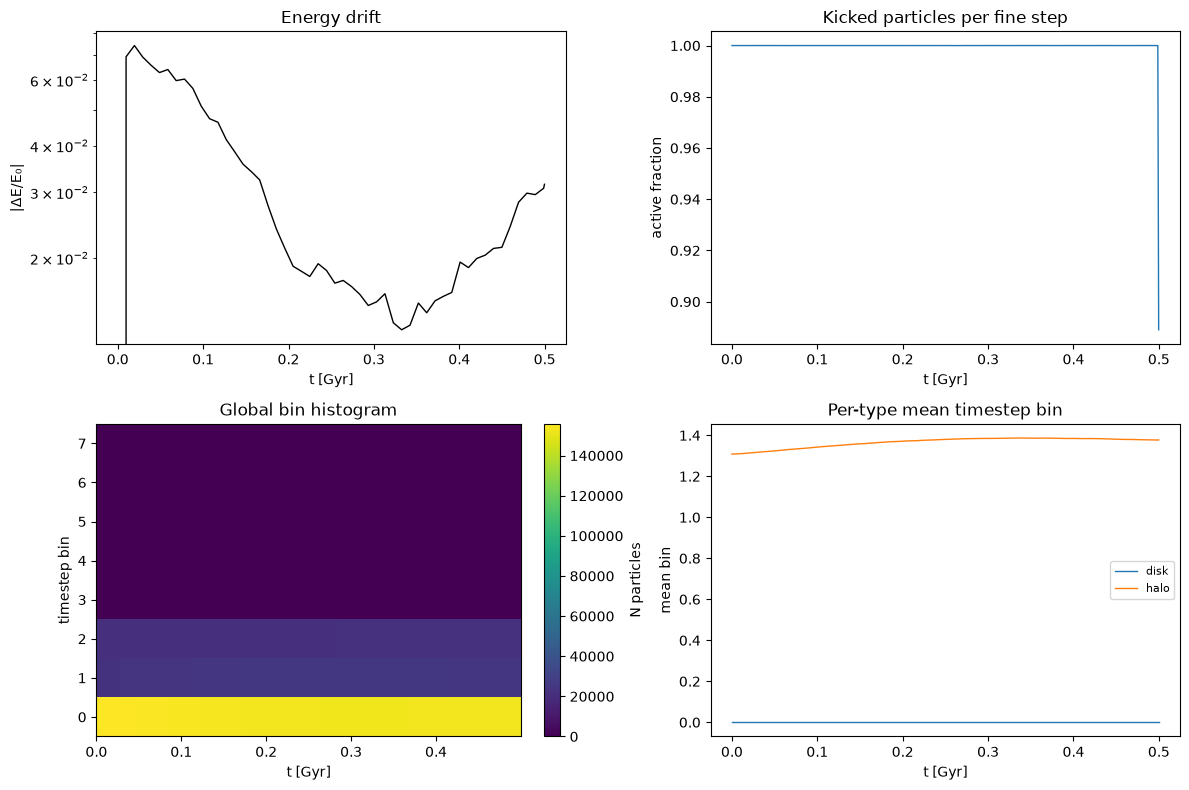

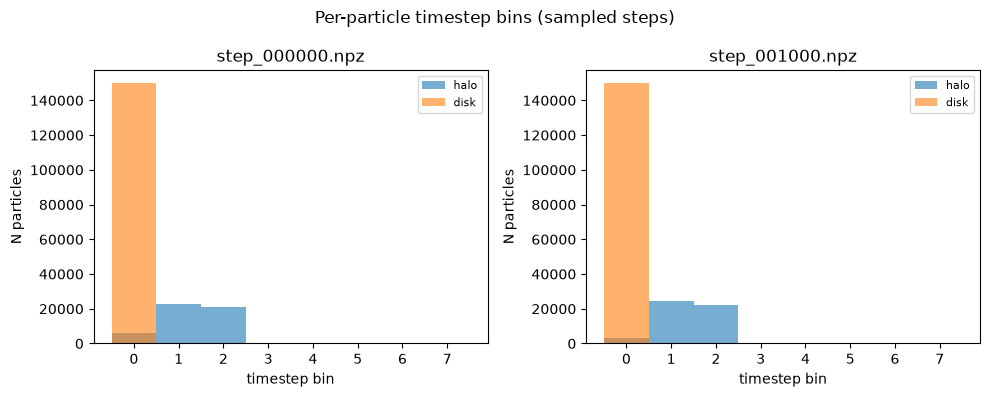

Saved base_ntropy_diagnostics.png


In [9]:
base_diag_dir = BASE_WORK_DIR / "evolution"
if not (base_diag_dir / "diagnostics.csv").exists():
    raise FileNotFoundError(
        f"Missing {base_diag_dir / 'diagnostics.csv'} — re-run base evolve with SKIP_DONE=False"
    )

base_diag_df, _ = load_run_diagnostics(BASE_WORK_DIR)
print(f"{len(base_diag_df)} diagnostic records, t = 0 … {base_diag_df.t_gyr.iloc[-1]:.4f} Gyr")

fig = plot_tiered_diagnostics(base_diag_df)
diag_fig_path = ARTIFACTS / "base_ntropy_diagnostics.png"
fig.savefig(diag_fig_path, dpi=150, bbox_inches="tight")
plt.show()

particle_dir = base_diag_dir / "particles"
npz_files = sorted(particle_dir.glob("step_*.npz"))
if npz_files:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, path in zip(axes, [npz_files[0], npz_files[-1]]):
        data = np.load(path)
        bins = data["timestep_bin"]
        type_id = data["type_id"]
        for tid, label, color in [(1, "halo", "C0"), (3, "disk", "C1")]:
            mask = type_id == tid
            if np.any(mask):
                ax.hist(bins[mask], bins=np.arange(-0.5, 8.5, 1), alpha=0.6, label=label, color=color)
        ax.set_xlabel("timestep bin")
        ax.set_ylabel("N particles")
        ax.set_title(path.name)
        ax.legend(fontsize=8)
    fig.suptitle("Per-particle timestep bins (sampled steps)")
    fig.tight_layout()
    plt.show()
else:
    print("No particle bin dumps in", particle_dir)
print(f"Saved {diag_fig_path.name}")

## 2. Define and inspect the parameter sweep

Mini grid (two halo circular velocities) based on `campaigns/mw_grid.json`, using the same DBH grid knobs as the base case (`DBH_COARSE_GRID`, `DBH_NR`, etc.).

Compare sweep outputs in later sections against the **base reference** in `BASE_WORK_DIR`.

In [7]:
SWEEP_SPEC = CFG.sweep_grid()
if SWEEP_SPEC is None:
    print("Sweep disabled in mw_walkthrough.json (set sweep.enabled=true to run)")
else:
    grid_models = expand_grid(SWEEP_SPEC)
    grid_df = pd.DataFrame(
        {
            "label": [label for label, _ in grid_models],
            "halo_v0": [m.halo.v0 if m.halo else None for _, m in grid_models],
            "disk_mass": [m.disk.mass if m.disk else None for _, m in grid_models],
            "grid_nr": [m.grid.nr for _, m in grid_models],
        }
    )
    display(grid_df)

Sweep disabled in mw_walkthrough.json (set sweep.enabled=true to run)


## 3. Run the parameter sweep (solve → sample → evolve)

After validating the base case, run the mini halo-velocity sweep with the same pipeline as section 1:

1. **solve** — Python self-consistent `dbh` (disk + halo)
2. **sample** — OpenMP C disk/halo samplers when `sample.use_openmp` and extension built (`N_DISK` + `N_HALO`)
3. **evolve** — ntropy tiered leapfrog to `END_TIME_GYR` (`MPI_RANKS=2` by default, `CORE_FRACTION=0.75`)

Set `SKIP_DONE = False` or delete `CAMPAIGN_ROOT` to re-run sweep points after config changes. The manifest (`campaign_index.csv`) records wall times and |ΔE/E₀|. With `VERBOSE_CAMPAIGN = True` (default), `run_campaign` prints timestamped stage logs and tails ntropy evolve lines (also written to `evolution/diagnostics.progress.jsonl`).

In [8]:
if SWEEP_SPEC is None:
    manifest_df = pd.DataFrame()
else:
    sweep_kw = CFG.run_campaign_kwargs()
    sweep_extra = sweep_kw.pop("bh_optimizations_extra", None)
    manifest = run_campaign(
        SWEEP_SPEC,
        CAMPAIGN_ROOT,
        bh_optimizations_extra=sweep_extra,
        **sweep_kw,
    )
    manifest_df = pd.DataFrame(manifest.rows)
manifest_df

""


## 4. Load a sweep point for detailed analysis

Pick one grid point (default: first row) and reload its ICs and evolved state. The analysis below mirrors section 1b for a single sweep variant.

In [9]:
EXAMPLE_IDX = 0
example = manifest_df.iloc[EXAMPLE_IDX]
work_dir = Path(example["path"])
print(f"Sweep model: {example['label']}\nWork dir: {work_dir}")
print(f"Base reference: {BASE_WORK_DIR}")

initial_state = load_merged_state(work_dir)
final_state = load_evolved_state(work_dir, initial_state)

print(f"N = {initial_state.n:,} particles")
for label in registry.types:
    mask = initial_state.tags == label
    if np.any(mask):
        print(f"  {label:5s}: {mask.sum():6,d}")

IndexError: single positional indexer is out-of-bounds

### 4a. Sweep point — initial density and disk projections (t = 0)

In [ ]:
halo_init = halo_spherical_profile(initial_state)
disk_init = disk_surface_profile(initial_state)
face_init, edge_init = disk_projections(initial_state)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].loglog(halo_init.r_mid[halo_init.counts > 0], halo_init.rho[halo_init.counts > 0], "o-", ms=4)
axes[0].set_xlabel("r [kpc]")
axes[0].set_ylabel("ρ [M_unit / kpc³]")
axes[0].set_title(f"Halo ρ(r) — {example['label']} (t=0)")

axes[1].semilogy(disk_init.r_mid[disk_init.counts > 0], disk_init.sigma[disk_init.counts > 0], "o-", ms=4)
axes[1].set_xlabel("R [kpc]")
axes[1].set_ylabel("Σ [M_unit / kpc²]")
axes[1].set_title("Disk Σ(R) — t=0")

im = plot_density_map(axes[2], face_init, title="Disk face-on (log Σ)")
axes[2].set_xlabel("x [kpc]")
axes[2].set_ylabel("y [kpc]")
fig.colorbar(im, ax=axes[2], fraction=0.046, label="log₁₀ Σ")
fig.tight_layout()
init_path = ARTIFACTS / "sweep_initial_density.png"
fig.savefig(init_path, dpi=150)
plt.show()
print(f"Saved {init_path.name}")

### 4b. Edge-on disk projections (sweep point, t = 0)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
proj_vmin, proj_vmax = density_map_color_limits(face_init, edge_init)
im0 = plot_density_map(axes[0], face_init, title="Face-on (x–y)", vmin=proj_vmin, vmax=proj_vmax)
axes[0].set_xlabel("x [kpc]")
axes[0].set_ylabel("y [kpc]")
im1 = plot_density_map(axes[1], edge_init, title="Edge-on (x–z, |z| < 0.3 kpc)", vmin=proj_vmin, vmax=proj_vmax)
axes[1].set_xlabel("x [kpc]")
axes[1].set_ylabel("z [kpc]")
fig.colorbar(im0, ax=axes[0], fraction=0.046, label="log₁₀ Σ")
fig.colorbar(im1, ax=axes[1], fraction=0.046, label="log₁₀ Σ")
fig.tight_layout()
proj_path = ARTIFACTS / "sweep_disk_projections_initial.png"
fig.savefig(proj_path, dpi=150)
plt.show()
print(f"Saved {proj_path.name}")

In [ ]:
# Quick comparison: sweep point vs base reference (final disk Σ)
fig, ax = plt.subplots(figsize=(7, 4))
for st, label, style in (
    (base_final, "base MW", "k-"),
    (final_state, example["label"], "C1--"),
):
    if st is None:
        continue
    prof = disk_surface_profile(st)
    valid = prof.counts > 10
    ax.semilogy(prof.r_mid[valid], prof.sigma[valid], style, label=label, ms=3)
ax.set_xlabel("R [kpc]")
ax.set_ylabel("Σ [M_unit / kpc²]")
ax.set_title(f"Final disk Σ(R) vs base ({END_TIME_GYR:.2f} Gyr)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### 4c. Sweep point — ntropy diagnostics

Same per-substep bin / activity traces for the selected sweep variant (`work_dir`).

In [ ]:
sweep_diag_df, sweep_diag_dir = load_run_diagnostics(work_dir)
fig = plot_tiered_diagnostics(sweep_diag_df)
fig.suptitle(f"ntropy diagnostics — {example['label']}", y=1.02)
fig.savefig(ARTIFACTS / "sweep_ntropy_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Time-resolved evolution with checkpoints

By default (`REEVOLVE_FOR_CHECKPOINTS = False`) we compare **initial ICs** vs the campaign's **`evolution/final.dat`** — avoiding a second 200k-particle integration.

Set `REEVOLVE_FOR_CHECKPOINTS = True` to re-integrate from ICs in segments at `CHECKPOINT_GYR` (same tiered leapfrog as the campaign, but much slower).

When `REEVOLVE_FOR_CHECKPOINTS = False`, §5 loads intermediate times from **campaign particle dumps** via `load_evolution_checkpoints()` (same helper as §1b) instead of integrating only IC + `final.dat`.


In [ ]:
def make_accel_fn(state: ParticleState, registry: TypeRegistry):
    from ntropy.forces.bhtree_c import compute_forces_bh_c, extension_available
    from ntropy.forces.bhtree import compute_forces_bh

    use_c = extension_available()
    theta = float(CONFIG.get("force", {}).get("theta", 0.5))

    def accel(pos: np.ndarray, active_idx: np.ndarray | None = None) -> np.ndarray:
        # Tiered leapfrog may pass active_idx; return a full (N, 3) array.
        if active_idx is None or len(active_idx) >= pos.shape[0]:
            if use_c:
                return compute_forces_bh_c(pos, state.mass, state.eps, theta=theta)
            return compute_forces_bh(pos, state.mass, state.eps, theta=theta)
        cache = np.zeros((pos.shape[0], 3), dtype=float)
        if use_c:
            cache[active_idx] = compute_forces_bh_c(
                pos, state.mass, state.eps, theta=theta, target_indices=active_idx
            )
        else:
            cache[active_idx] = compute_forces_bh(
                pos, state.mass, state.eps, theta=theta, target_indices=active_idx
            )
        return cache

    return accel


def evolve_with_checkpoints(
    state0: ParticleState,
    checkpoint_gyr: list[float],
    *,
    registry: TypeRegistry,
    ts_config: TimestepConfig | None = None,
) -> tuple[list[tuple[float, ParticleState]], list[float]]:
    ts_config = ts_config or EVOLVE_TIMESTEP
    state = state0.copy()
    accel_fn = make_accel_fn(state, registry)
    checkpoints: list[tuple[float, ParticleState]] = [(checkpoint_gyr[0], state0.copy())]
    energies: list[float] = [total_energy(state.pos, state.vel, state.mass, state.eps)]

    for t_prev, t_end in zip(checkpoint_gyr[:-1], checkpoint_gyr[1:]):
        dt_gyr = t_end - t_prev
        state, seg_energies, _diag = run_tiered_leapfrog(
            state, registry, accel_fn,
            ts_config=ts_config, end_time_gyr=dt_gyr, order=INTEGRATOR_ORDER, energy_every=0,
            diagnostics_every=0,
        )
        if seg_energies:
            energies.extend(seg_energies[1:])
        checkpoints.append((t_end, state.copy()))

    return checkpoints, energies


ts_config = EVOLVE_TIMESTEP

if REEVOLVE_FOR_CHECKPOINTS:
    checkpoints, checkpoint_energies = evolve_with_checkpoints(
        initial_state, CHECKPOINT_GYR, registry=registry, ts_config=ts_config,
    )
else:
    checkpoints = load_evolution_checkpoints(
        work_dir,
        CHECKPOINT_GYR,
        template=initial_state,
        end_time_gyr=END_TIME_GYR,
    )
    if len(checkpoints) < 2:
        raise FileNotFoundError(
            f"Need evolution/final.dat (and optional particles/step_*.npz) in {work_dir}"
        )
    checkpoint_energies = [
        total_energy(st.pos, st.vel, st.mass, st.eps) for _, st in checkpoints
    ]

print(f"{len(checkpoints)} time slices: ", ", ".join(f"{t:.3f} Gyr" for t, _ in checkpoints))


### 5a. Density profile drift vs time

For a good equilibrium IC, spherical halo ρ(r) and disk Σ(R) should be stable over a few dynamical times — large drift signals poor IC quality, timestep issues, or violence from disk+halo coupling.

In [ ]:
ref_halo = halo_spherical_profile(checkpoints[0][1])
ref_disk = disk_surface_profile(checkpoints[0][1])

halo_drifts, disk_drifts, times = [], [], []
for t_gyr, st in checkpoints[1:]:
    hp = halo_spherical_profile(st)
    dp = disk_surface_profile(st)
    halo_drifts.append(compare_density_profiles(ref_halo, hp, min_count=5))
    disk_drifts.append(compare_surface_profiles(ref_disk, dp, min_count=5))
    times.append(t_gyr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, profiles, title, ylabel in (
    (axes[0], [halo_spherical_profile(st) for _, st in checkpoints], "Halo ρ(r)", "ρ"),
    (axes[1], [disk_surface_profile(st) for _, st in checkpoints], "Disk Σ(R)", "Σ"),
):
    cmap = plt.cm.viridis(np.linspace(0.15, 0.95, len(checkpoints)))
    for (t_gyr, _), prof, color in zip(checkpoints, profiles, cmap):
        valid = prof.counts > 0
        if title.startswith("Halo"):
            ax.loglog(prof.r_mid[valid], prof.rho[valid], color=color, alpha=0.85, label=f"{t_gyr:.3f} Gyr")
        else:
            ax.semilogy(prof.r_mid[valid], prof.sigma[valid], color=color, alpha=0.85, label=f"{t_gyr:.3f} Gyr")
    ax.set_xlabel("r or R [kpc]")
    ax.set_ylabel(f"{ylabel} [code units]")
    ax.set_title(title)
    ax.legend(fontsize=8)
fig.tight_layout()
drift_path = ARTIFACTS / "density_evolution.png"
fig.savefig(drift_path, dpi=150)
plt.show()

e0 = max(abs(checkpoint_energies[0]), 1e-30)
dE = [abs(e - checkpoint_energies[0]) / e0 for e in checkpoint_energies]
print("Max relative halo ρ drift:", max(halo_drifts) if halo_drifts else 0.0)
print("Max relative disk Σ drift:", max(disk_drifts) if disk_drifts else 0.0)
print(f"|ΔE/E₀| at end: {dE[-1]:.3e}")

### 5b. Disk projections through time

Face-on maps at $t=0$ are axisymmetric (GalactICS equilibrium ICs). Over **multi-Gyr** evolution, shot noise and swing amplification can grow spirals and bars without an external perturbation ([Bauer & Widrow 2018](https://arxiv.org/pdf/1809.00090v1)). Edge-on maps track vertical heating. This walkthrough's 0.5 Gyr screen is usually too short to see strong $m=2$ structure — use `campaigns/bauer_morphology.json` for morphology runs.

In [ ]:
n_times = len(checkpoints)
fig, axes = plt.subplots(2, n_times, figsize=(3.2 * n_times, 6.5), squeeze=False)

faces = []
edges = []
for _, st in checkpoints:
    face, edge = disk_projections(st)
    faces.append(face)
    edges.append(edge)
face_vmin, face_vmax = density_map_color_limits(*faces)
edge_vmin, edge_vmax = density_map_color_limits(*edges)

for col, (t_gyr, st) in enumerate(checkpoints):
    face, edge = faces[col], edges[col]
    im0 = plot_density_map(axes[0, col], face, title=f"Face-on t={t_gyr:.3f} Gyr", vmin=face_vmin, vmax=face_vmax)
    im1 = plot_density_map(axes[1, col], edge, title=f"Edge-on t={t_gyr:.3f} Gyr", vmin=edge_vmin, vmax=edge_vmax)
    axes[0, col].set_xlabel("x [kpc]")
    axes[1, col].set_xlabel("x [kpc]")
    if col == 0:
        axes[0, col].set_ylabel("y [kpc]")
        axes[1, col].set_ylabel("z [kpc]")

fig.colorbar(im0, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02, label="log₁₀ Σ")
fig.suptitle("Disk surface-density projections", y=1.02)
fig.tight_layout()
movie_path = ARTIFACTS / "disk_projections_evolution.png"
fig.savefig(movie_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {movie_path.name}")

## 6. Compare sweep points (and base reference)

Overlay final disk Σ(R) for each sweep variant against the **base Milky Way** run from section 1.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

base_prof = disk_surface_profile(base_final)
vb = base_prof.counts > 10
ax.semilogy(base_prof.r_mid[vb], base_prof.sigma[vb], "k-", lw=2, label="base MW")

colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(manifest_df)))
for color, row in zip(colors, manifest_df.itertuples()):
    model_dir = Path(row.path)
    template = load_merged_state(model_dir)
    st = load_evolved_state(model_dir, template) or template
    prof = disk_surface_profile(st)
    valid = prof.counts > 10
    ax.semilogy(
        prof.r_mid[valid], prof.sigma[valid], color=color,
        label=f"{row.label}  ΔE/E₀={getattr(row, 'dE_over_E0', float('nan')):.2e}",
    )

ax.set_xlabel("R [kpc]")
ax.set_ylabel("Σ [M_unit / kpc²]")
ax.set_title(f"Final disk Σ(R) — base + sweep ({END_TIME_GYR:.2f} Gyr)")
ax.legend(fontsize=8)
fig.tight_layout()
grid_path = ARTIFACTS / "campaign_grid_comparison.png"
fig.savefig(grid_path, dpi=150)
plt.show()
print(f"Saved {grid_path.name}")

## Next steps

- Set `REEVOLVE_FOR_CHECKPOINTS = True` and denser `CHECKPOINT_GYR` for time-resolved movies (slow at large N)
- **Tighter screening:** `end_time_gyr=0.1`, `max_timestep_bin=5`, `particles.halo=100_000`, `force.theta=0.45`
- **Spiral / bar morphology:** `end_time_gyr≥5` with `campaigns/bauer_morphology.json` ($Q\sim 2.34$, $\varepsilon=0.15$ kpc); track $A_2/A_0$ (Bauer & Widrow Fig. 4)
- **GPU BH single-galaxy run:** [`gpu_bh_dbh.ipynb`](gpu_bh_dbh.ipynb) (IC potential virial + adaptive GPU evolution)
- **Halo-only force / scaling deep-dive:** [`nfw_halo_walkthrough.ipynb`](nfw_halo_walkthrough.ipynb)
- Full factorial grid: `campaigns/mw_grid.json` (`coarse_grid: false` for production)
- PR regression gate: `make test-essential` · [`docs/ci_essential.md`](../docs/ci_essential.md)
- ML encoders: [`docs/ml_representation_roadmap.md`](../docs/ml_representation_roadmap.md) · `examples/export_particle_features.py`
